In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams['font.family'] = 'Helvetica'
from countryinfo import CountryInfo

available_countries = CountryInfo().all()
# Define the regions that constitute the Americas
americas_continents = ['North America', 'South America', 'Central America', 'Caribbean']

sample = list(available_countries.values())[0]
print(sample.keys())
# Extract unique continents (optional)
unique_regions = set(
    country['region'] for country in available_countries.values() if 'region' in country
)
print("Unique Regions in Dataset:", unique_regions)

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])


def basic_formatting( ax, spines=["bottom"], which="y", title=None, ylabel=None, xlabel=None, xsize=12, ysize=12, xlims=None, ylims=None ):
    """
    Specifies the basic formatting of all plots.
    """
    # Remove spines
    [ax.spines[j].set_visible( False ) for j in ax.spines if j not in spines]

    # Format axes ticks
    ax.tick_params( axis="x", bottom=False, which="both", labelbottom=True, labelsize=xsize, pad=0 )
    ax.tick_params( axis="y", left=False, which="both", labelleft=True, labelsize=ysize, pad=0 )

    # Label axes
    ax.set_xlabel( xlabel, fontsize=xsize )
    ax.set_ylabel( ylabel, fontsize=ysize )
    ax.set_title( title )

    ax.set_facecolor( "w" )

    # Add a simple grid
    ax.grid( which="both", axis=which, linewidth=1, color="#F1F1F1", zorder=1 )

    # Add the xlims
    if xlims:
        ax.set_xlim( xlims )
    if ylims:
        ax.set_ylim( ylims )


# Filter countries in the Americas and extract their names
americas_regions = ['Americas']  # This is the correct label used by your data

american_countries = [
    country['name'] for country in available_countries.values()
    if country.get('region') in americas_regions
]

print("\nCountries in the Americas:")
for name in american_countries:
    print(name)

dict_keys(['name', 'altSpellings', 'area', 'borders', 'callingCodes', 'capital', 'capital_latlng', 'currencies', 'demonym', 'flag', 'geoJSON', 'ISO', 'languages', 'latlng', 'nativeName', 'population', 'provinces', 'region', 'subregion', 'timezones', 'tld', 'translations', 'wiki'])
Unique Regions in Dataset: {'', 'Europe', 'Africa', 'Oceania', 'Asia', 'Americas'}

Countries in the Americas:
Greenland
Montserrat
Panama
Bermuda
South Georgia
Saint Pierre and Miquelon
Brazil
Falkland Islands
Mexico
Dominica
United States
Martinique
Jamaica
Guatemala
Barbados
Suriname
Uruguay
Argentina
Grenada
Guyana
Saint Vincent and the Grenadines
Bolivia
Paraguay
Anguilla
Cayman Islands
Colombia
The Bahamas
Haiti
Canada
Saint Lucia
Cuba
Peru
Costa Rica
Saint Kitts and Nevis
Puerto Rico
Dominican Republic
French Guiana
Venezuela
Belize
Nicaragua
Chile
Guadeloupe
El Salvador
Ecuador
Aruba
Honduras
Antigua and Barbuda
Trinidad and Tobago


In [21]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import cartopy

# Read the GeoJSON file
world = gpd.read_file('/Users/ricardorivero/Documents/DENV/2024/world-administrative-boundaries.geojson')
world['name'] = world['name'].str.replace('United States of America', 'United States')
world['name'] = world['name'].str.replace('Bolivia (Plurinational State of)', 'Bolivia')
world['name'] = world['name'].str.replace('Venezuela (Bolivarian Republic of)', 'Venezuela')



# Filter for countries in the Americas
America = world[world['name'].isin(american_countries)]

# Define the color palette
palette = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Caribbean": "#9c6ade"
}

# Define the bounding box coordinates
minx, miny = -180, -57
maxx, maxy = -27, 84

# Create the bounding box
bbox = box(minx, miny, maxx, maxy)

# Convert the bounding box to a GeoDataFrame
bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox]}, crs="EPSG:4326")

# Clip the America GeoDataFrame with the bounding box
America_clipped = gpd.clip(America, bbox_gdf)

# Map colors based on country name
America_clipped['color'] = America_clipped['name'].map(palette)

# Handle countries without a specified color
America_clipped['color'] = America_clipped['color'].fillna('#A0A0A0')

# Define country coordinates (longitude, latitude)
country_coords = {
    "United States": (-81.760254, 	27.994402),
    "Colombia": (-74.2973, 4.5709),
    "Brazil": (-51.9253, -14.2350),
    "Peru": (-75.0152, -9.19),
    "Mexico": (-102.5528, 23.6345),
    "Ecuador": (-78.1834, -1.8312),
    "Bolivia": (-63.5887, -16.2902),
    "Central_America": (-85.2072, 15.7835),
    "Caribbean": (-77.781167, 21.52175),
    "Paraguay": (-58.4438, -23.4425),
    "Bangladesh": (90.3563, 23.6849),
    "Rest_SA" : (-66.916664, 10.500000)
}

# Read connections from CSV
#Replace USA with United States
MarkovJumps_map = pd.read_table('/Users/ricardorivero/Documents/DENV/2024/D2/F1112/NewJumpsF112.csv', sep=',')
#group by "from" country and filter out those with less than 1%
connections_df = MarkovJumps_map.groupby(['from', 'to']).size()
#filter out those with less than 1% of the total number of jumps
connections_df = connections_df[connections_df > 0.01*connections_df.sum()]

connections_df = connections_df.reset_index()
connections_df.columns = ['from', 'to', 'jumps']
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')
#create percentage column
connections_df['percentage_movements'] = connections_df['jumps']/connections_df['jumps'].sum()*100
print(connections_df['percentage_movements'])


def scale_bayes_factor(x, min_val=1, max_val=20, min_width=3, max_width=350):
    # Normalize x to the [0, 1] range based on the percentage scale (min_val to max_val)
    normalized_x = (x - min_val) / (max_val - min_val)
    
    # Scale the width between min_width and max_width based on the normalized value
    scaled_width = min_width + (normalized_x * (max_width - min_width))
    
    return scaled_width

connections_df['scaled_width'] = connections_df['percentage_movements'].apply(scale_bayes_factor)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.set_facecolor('#e8f1f8')
# Plot the clipped map with the specified colors
#Set function for Alpha
# Define the alpha function based on country membership in american_countries
alpha_func = lambda x: 0.4 if x in american_countries else 1

# Apply the function to the 'name' column and create a new column 'alpha'
America_clipped['alpha'] = America_clipped['name'].apply(alpha_func)

# Plot with varying alpha values

# Generate gradient background
# Define the latitude range (from miny to maxy)
lat_range = np.linspace(miny, maxy, 100)

# Create a 2D array where each row is a color between #e2eff8 and white (along the vertical axis)
colors = np.array([np.linspace(0.886, 1, 100),  # Red channel (from #e2eff8 to white)
                   np.linspace(0.937, 1, 100),  # Green channel (from #e2eff8 to white)
                   np.linspace(0.973, 1, 100)])  # Blue channel (from #e2eff8 to white)

# Convert to 3D array (100x1x3) and transpose it to make the gradient vertical
gradient = np.dstack([colors[0], colors[1], colors[2]])


# Use imshow to plot the gradient background
from scipy import ndimage

#rotated_gradient = ndimage.rotate(gradient, -90)
#ax.imshow(rotated_gradient, aspect='auto', extent=[minx, maxx, miny, maxy], origin='lower')

America_clipped.plot(ax=ax, color=America_clipped['color'], linewidth=1, edgecolor='k', alpha=America_clipped['alpha'])



# Function to draw curved arrows with thin black edges and fill color from origin country
def draw_curved_arrow(ax, start, end, bayes_factor, color, arrowstyle='->', mutation_scale=15):
    # Calculate the midpoint for curvature
    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2
    # Adjust the curvature
    delta_x = end[0] - start[0]
    delta_y = end[1] - start[1]
    curvature = -0.3  # Adjust for more or less curvature
    if delta_x == 0 and delta_y == 0:
        curvature = 0
    # Create a FancyArrowPatch with Bezier curve
    arrow = FancyArrowPatch(
        posA=start,
        posB=end,
        connectionstyle=f"arc3,rad={curvature}",
        arrowstyle=arrowstyle,
        facecolor=color,     # Fill color from origin country
        edgecolor=color,       # Thin black edge
        linewidth=np.log10(bayes_factor),         # Thin edge line
        mutation_scale=mutation_scale,
        zorder=5
    )
    ax.add_patch(arrow)

# Iterate through connections and draw arrows
for _, row in connections_df.iterrows():
    from_country = row["from"]
    to_country = row["to"]
    percentage_movements = row["percentage_movements"]
    
    # Get coordinates
    if from_country in country_coords and to_country in country_coords:
        start_lon, start_lat = country_coords[from_country]
        end_lon, end_lat = country_coords[to_country]
        color = palette.get(from_country, 'grey')  # Use the color of the starting country or grey if not found

        scaled_width = row["scaled_width"]
        
        # Draw the curved arrow
        draw_curved_arrow(
            ax,
            start=(start_lon, start_lat),
            end=(end_lon, end_lat),
            bayes_factor=scaled_width,  # Use the bayes.factor from the connection
            color=color,                # Fill color from origin country
            arrowstyle='-|>',           # Arrow style with a filled head
            mutation_scale=15           # Size of the arrow head
        )

start_x, start_y = -75.0152, -9.19  # Coordinates where the arrow starts
end_x, end_y = 90.3563, 23.6849 # Coordinates where the arrow ends

# Calculate the angle of the arrow for the correct text inclination
angle = np.degrees(np.arctan2(end_y - start_y, end_x - start_x))

# Add the text annotation, rotated with the same inclination as the arrow
plt.text(
    (start_x - end_x) / 5-10, (start_y + end_y)*1.1,  # Midpoint of the arrow for text location
    'Bangladesh',  # The text annotation
    fontsize=14,  # Adjust the font size as needed
    rotation=angle*2.45,  # Align the text to the arrow's angle
    ha='center', va='center',  # Center the text at its location
    color='black',  # Text color, adjust if needed
)

# --- Legend ---
# Define percentages and calculate line widths
percentages = [1, 10, 20]
line_widths = [scale_bayes_factor(p, min_val=1, max_val=60, min_width=1, max_width=10) for p in percentages]

# Add legend to the plot
legend_x = maxx - 140
legend_y_start = miny + 10
for i, (perc, width) in enumerate(zip(percentages, line_widths)):
    ax.plot([legend_x, legend_x + 10], [legend_y_start + i * 3, legend_y_start + i * 3], lw=width, color='black')
    ax.text(legend_x + 15, legend_y_start + i * 3, f'{perc}%', fontsize=12, verticalalignment='center')

# Add legend title
ax.text(legend_x, legend_y_start + 10, "Percentage of Posterior Movements", fontsize=14, verticalalignment='center')

# Remove axes
plt.axis('off')

# Center the plot by setting appropriate limits
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Save the plot as high-resolution SVG and JPEG
#plt.savefig('/Users/ricardorivero/Documents/DENV/2024/america_map.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/america_map_F1112_phylogeography.jpeg', format='jpeg', dpi=1200, bbox_inches='tight')
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/america_map_F1112_phylogeography.pdf', format='pdf', dpi=1200, bbox_inches='tight')

# Display the plot
plt.show()

KeyError: 'from'

In [10]:
#Violin plot of Markov connections_df from and to Colombia
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#Read the markov connections_df data
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the decimal/fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')  # Start of the year
    # Calculate the date by adding the fractional part as days
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

mrsd = 2024.62

connections_df = pd.read_csv('/Users/ricardorivero/Documents/DENV/2024/D2/F1112/NewJumpsF112.csv')

connections_df['time'] = pd.to_numeric(connections_df['time'], errors='coerce')
connections_df['time'] = mrsd - connections_df['time']
connections_df = connections_df[connections_df['time'] >= 2012]
connections_df['time'] = connections_df['time'].round(2)

# Convert time from decimal year to date
connections_df['time'] = connections_df['time'].apply(decimal_year_to_date)

# Format the date into 'yyyy-mm-dd' format
connections_df['time'] = connections_df['time'].dt.strftime('%Y-%m-%d')

#replace USA with United States
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')

# Step 1: Create the "movement" column by concatenating "from" and "to"
connections_df["movement"] = connections_df["from"].str.capitalize() + "To" + connections_df["to"].str.capitalize()

# Step 2: Calculate the total number of movements
total_movements = len(connections_df)

# Step 3: Group by "movement" and count the occurrences
movement_counts = connections_df["movement"].value_counts()

# Step 4: Determine the 1% threshold
threshold = total_movements * 0.01

# Step 5: Filter out movements that are less than 1% of the total movements
valid_movements = movement_counts[movement_counts >= threshold].index
filtered_df = connections_df[connections_df["movement"].isin(valid_movements)].copy()
#Filter for Colombia
filtered_df = filtered_df[filtered_df["movement"].str.contains("Colombia", case=False)]
# Step 6: Check the resulting dataframe
filtered_df.head()



['Brazil' 'Colombia' 'Ecuador' 'United States']


In [5]:
from scipy.signal import savgol_filter
from matplotlib.lines import Line2D
from matplotlib import ticker
from matplotlib.ticker import PercentFormatter

plt.rcParams['font.family'] = 'Helvetica'

def skipped_timeseries_formatting(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    formatter = mdates.DateFormatter('%b')
    long_formatter = mdates.DateFormatter('%b\n%Y')
    accepted_months = ["Jan", "Jun"]
    labels = []
    for date in ax.get_xticks():
        formatted_date = formatter.format_data(date)
        if formatted_date in accepted_months:
            if formatted_date == "Jan":
                labels.append(long_formatter.format_data(date))
            else:
                labels.append(formatted_date)
        else:
            labels.append("")
    ax.set_xticklabels(labels)

palette = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "United States": "#bd0a31",
    "Bangladesh": "#B56A7A"
}
COLOR = '#343434'
# Define mrsd and load data
mrsd = 2024.62

connections_df = pd.read_csv('/Users/ricardorivero/Documents/DENV/2024/D2/F1112/NewJumpsF112.csv')

# Convert 'time' to decimal and then to date
connections_df['time'] = pd.to_numeric(connections_df['time'], errors='coerce')
connections_df['time'] = mrsd - connections_df['time']
connections_df = connections_df[connections_df['time'] >= 2012]
connections_df['time'] = connections_df['time'].round(2)
connections_df['time'] = connections_df['time'].apply(decimal_year_to_date)  # Convert to date

# Filter outliers in time
connections_df = connections_df[connections_df['time'] >= pd.Timestamp('2018-01-01')]

# Replace 'USA' with 'United States'
connections_df['from'] = connections_df['from'].str.replace('USA', 'United States')
connections_df['to'] = connections_df['to'].str.replace('USA', 'United States')

# Create the 'movement' column
connections_df["movement"] = connections_df["from"].str.capitalize() + "To" + connections_df["to"].str.capitalize()

# Calculate total number of movements and filter out those less than 1%
total_movements = len(connections_df)
movement_counts = connections_df["movement"].value_counts()
threshold = total_movements * 0.01
valid_movements = movement_counts[movement_counts >= threshold].index
filtered_df = connections_df[connections_df["movement"].isin(valid_movements)].copy()

# Filter for Colombia
jumps = filtered_df[filtered_df["to"] == "Colombia"].copy()
location = "Colombia"

# Create pivot table for plotting
sd_jumps = jumps.loc[(jumps["from"] == location) | (jumps["to"] == location)].copy()
sd_jumps.loc[sd_jumps["to"] == location, "to"] = sd_jumps["from"]
sd_jumps["from"] = location
plot_df = sd_jumps.pivot_table(index="time", columns="to", values="from", aggfunc="count", fill_value=0)
plot_df = plot_df.apply(lambda x: savgol_filter(x, window_length=min(31, len(x)), polyorder=3))
plot_df = plot_df.clip(lower=0)
plot_df = plot_df.apply(lambda x: x / x.sum(), axis=1)
plot_df = plot_df.reindex(columns=sd_jumps["to"].value_counts().sort_values().index)

jumps_mag = sd_jumps.pivot_table(index="time", values="from", aggfunc="count", fill_value=0)
jumps_mag["from"] = savgol_filter(jumps_mag["from"], window_length=min(31, len(jumps_mag)), polyorder=3)
jumps_mag = jumps_mag / jumps_mag.max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 5), dpi=1200, nrows=2, sharex=True,
                       gridspec_kw={"height_ratios": (0.2, 1), "hspace": 0.05})
ax[0].plot(jumps_mag.index, jumps_mag["from"], color=COLOR, zorder=9)
ax[0].fill_between(jumps_mag.index, jumps_mag["from"], color=COLOR, alpha=0.8, zorder=8)

# Handle column types
try:
    plot_df.columns = pd.to_datetime(plot_df.columns).floor('D')
except ValueError:
    pass

# Plot stackplot
ax[1].stackplot(plot_df.index, plot_df.T, labels=plot_df.columns, zorder=9,
                colors=[palette[i] for i in plot_df.columns], alpha=0.7, linewidth=2)

baseline = np.zeros(len(plot_df))
for i in plot_df:
    if i != plot_df.columns[-1]:
        ax[1].plot(plot_df.index, plot_df[i] + baseline, color=COLOR, zorder=10, linewidth=1)
        baseline += plot_df[i]

legend = []
for col in reversed(plot_df.columns):
    legend.append(Line2D([0], [0], linestyle='none', marker='s', color=palette[col] + "7F", markeredgecolor="black", label=col, markersize=12.5))

ax[0].legend(handles=legend, loc="upper center", bbox_to_anchor=(0, 0, 1, 1.55), handletextpad=0.1, frameon=False, fontsize=11, ncol=len(legend))

# Format and display plot
basic_formatting(ax[1], spines=["bottom"], which="both", xlims=(pd.to_datetime("2018-01-01"), pd.to_datetime("2024-09-01")),
                 ylims=(0, 1), ylabel="Percentage of Markov jumps", xsize=12.5, ysize=12.5)
skipped_timeseries_formatting(ax[1])
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax[1].tick_params(axis="y", pad=2.5)

basic_formatting(ax[0], spines=["bottom"], which="both", ylims=(0, 1.05), ylabel="Density", ysize=12.5, xsize=12.5)
skipped_timeseries_formatting(ax[0])
ax[0].set_yticks([0, 1])
ax[0].set_yticklabels([])
ax[0].label_outer()

plt.tight_layout()
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D2/F1112_MarkovJumps_all.jpeg', format='jpeg', dpi=1200, bbox_inches='tight')
plt.show

/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_29459/535973060.py:92: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plot_df.columns = pd.to_datetime(plot_df.columns).floor('D')


NameError: name 'np' is not defined

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Helper function to convert decimal year to date
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

def process_and_test_bridge_role_with_time(csv_path):
    """
    Reads a CSV with reconstructed Markov jumps, processes the time column to create a numeric decimal date,
    assigns regions to countries, flags jumps involving Colombia, and creates a movement 'direction'.
    Then the data is aggregated by year and direction under two scenarios:
      (1) Including all jumps (i.e. "with Colombia", which is all interregional jumps)
      (2) Excluding jumps that involve Colombia ("without Colombia").
    A Poisson GLM is then fitted that includes time (year) as a predictor.
    
    Parameters:
      csv_path (str): Path to the CSV file.
      
    Returns:
      agg_all (DataFrame): Aggregated counts by year, condition, and direction.
      model (GLMResults): Fitted Poisson GLM.
    """
    # Parameters for time processing
    mrsd = 2024.62  # reference value
    
    # Read CSV and process the time column
    df = pd.read_csv(csv_path)
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    # Transform time to a decimal date by subtracting the recorded time from mrsd.
    df['time'] = mrsd - df['time']
    df = df[df['time'] >= 2018]  # filter out early times if needed
    df['time'] = df['time'].round(2)
    # Save the numeric decimal time for modeling:
    df['time_decimal'] = df['time']
    # Optionally, convert the decimal time to an actual date string (for plotting/display)
    df['time'] = df['time'].apply(decimal_year_to_date)
    df['time'] = df['time'].dt.strftime('%Y-%m-%d')
    # Extract the year (as integer) from the decimal time for aggregation
    df['year'] = df['time_decimal'].astype(int)
    # Assuming df['year'] is already extracted from your data:
    df['year_centered'] = df['year'] - 2018
    
    # Standardize country names: replace 'USA' with 'United States'
    df['from'] = df['from'].str.replace('USA', 'United States', regex=False)
    df['to']   = df['to'].str.replace('USA', 'United States', regex=False)
    
    # Create the "movement" column (for exploration)
    df["movement"] = df["from"].str.capitalize() + "To" + df["to"].str.capitalize()
    
    # Flag jumps that involve Colombia (if either origin or destination is Colombia)
    df['involves_colombia'] = df[['from', 'to']].apply(
        lambda x: 'Colombia' in [val.strip().title() for val in x], axis=1)
    
    # Define mapping of countries to regions.
    region_map = {
        'United States': 'North America',
        # Add other North American countries as needed.
        'Colombia': 'South America',
        'Brazil': 'South America',
        'Ecuador': 'South America',
        # Add any other countries as needed.
    }
    def map_region(country):
        country_std = country.strip().title()
        return region_map.get(country_std, 'Other')
    
    df['from_region'] = df['from'].apply(map_region)
    df['to_region']   = df['to'].apply(map_region)
    
    # Define movement direction: consider only inter-regional movements between North and South America.
    def get_direction(row):
        if row['from_region'] == row['to_region']:
            return 'intra'
        elif row['from_region'] == 'North America' and row['to_region'] == 'South America':
            return 'NorthToSouth'
        elif row['from_region'] == 'South America' and row['to_region'] == 'North America':
            return 'SouthToNorth'
        else:
            return 'other'
    
    df['direction'] = df.apply(get_direction, axis=1)
    
    # Focus on inter-regional movements of interest.
    df_inter = df[df['direction'].isin(['NorthToSouth', 'SouthToNorth'])].copy()
    
    # Scenario 1: "With Colombia" = all inter-regional jumps (including those that involve Colombia)
    agg_with = df_inter.groupby(['year_centered', 'direction']).size().reset_index(name='count')
    agg_with['condition'] = 'With'
    
    # Scenario 2: "Without Colombia" = only those jumps that do NOT involve Colombia
    df_without = df_inter[df_inter['involves_colombia'] == False]
    agg_without = df_without.groupby(['year_centered', 'direction']).size().reset_index(name='count')
    agg_without['condition'] = 'Without'
    
    # Combine aggregated data
    agg_all = pd.concat([agg_with, agg_without], ignore_index=True)
    print("Aggregated counts by year, condition, and direction:")
    print(agg_all)
    
    # Fit a Poisson GLM that includes time (year) as a continuous predictor.
    # This model tests whether the counts vary by condition, direction, and year.
    model = smf.glm(formula="count ~ np.power(year_centered, 2) + year_centered + condition + direction", 
                    data=agg_all, 
                    family=sm.families.Poisson()).fit()
    print("\nGLM Summary with time as a predictor:")
    print(model.summary())
    
    return agg_all, model

# Example usage:
csv_path = '/Users/ricardorivero/Documents/DENV/2024/D2/F1112/allJumps_F112.csv'
agg_all, glm_model = process_and_test_bridge_role_with_time(csv_path)

Aggregated counts by year, condition, and direction:
    year_centered     direction  count condition
0               0  NorthToSouth    178      With
1               0  SouthToNorth    181      With
2               1  NorthToSouth    216      With
3               1  SouthToNorth    204      With
4               2  NorthToSouth    571      With
5               2  SouthToNorth    514      With
6               3  NorthToSouth    646      With
7               3  SouthToNorth   1328      With
8               4  NorthToSouth   1354      With
9               4  SouthToNorth   6476      With
10              5  NorthToSouth   8755      With
11              5  SouthToNorth  64800      With
12              6  NorthToSouth   1167      With
13              6  SouthToNorth  38641      With
14              0  NorthToSouth     81   Without
15              0  SouthToNorth    134   Without
16              1  NorthToSouth    110   Without
17              1  SouthToNorth    182   Without
18              

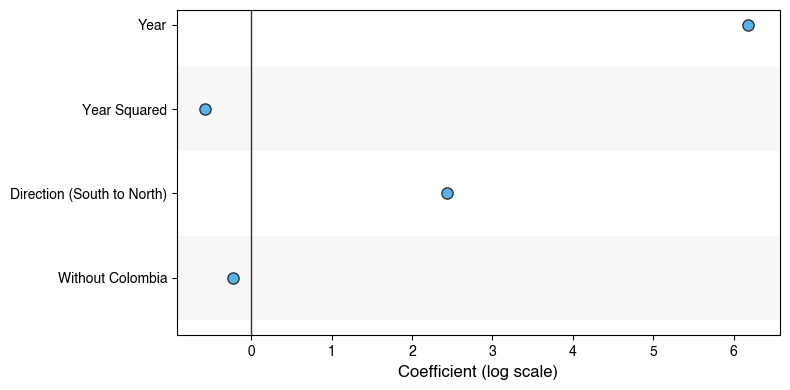

In [28]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

label_map = {"year_centered": "Year", "count": "Count", "condition": "", "direction": "Direction"}

def create_coef_df(model):
    coef_df = pd.DataFrame({
        "variable": model.params.index,
        "coef": model.params.values,
        "lower": model.conf_int()[0].values,
        "upper": model.conf_int()[1].values
    })
    # Remove the intercept
    coef_df = coef_df[coef_df["variable"] != "Intercept"]
    
    # Rename variables if desired
    rename_dict = {
        "year_centered": "Year",
        "np.power(year_centered, 2)": "Year Squared",
        "direction[T.SouthToNorth]": "Direction (South to North)",
        "condition[T.Without]": "Without Colombia"
    }
    coef_df["variable"] = coef_df["variable"].replace(rename_dict)
    
    # Now reset the index so it's consecutive
    coef_df.reset_index(drop=True, inplace=True)
    return coef_df

def plot_forest(ax, df):
    # Plot coefficient estimates as scatter points.
    ax.scatter(df["coef"], df.index, s=65, color="#56B4E9", zorder=5, 
               edgecolor="#333333", linewidths=1)
    # Plot horizontal error bars for confidence intervals.
    ln = ax.hlines(df.index, xmin=df["lower"], xmax=df["upper"], color="#56B4E9", 
                   linewidth=2, zorder=4)
    ln.set_capstyle("round")
    
    # Add a vertical line at zero.
    ax.axvline(0, color="#333333", linewidth=1, zorder=2)
    
    # Set y-ticks and labels.
    ax.set_yticks(df.index)
    ax.set_yticklabels(df["variable"], fontsize=10)
    ax.set_xlabel("Coefficient (log scale)", fontsize=12)
    ax.tick_params(axis="x", which="both", rotation=0, pad=4)
    
    # Optional: add horizontal shading for alternate rows for clarity.
    for i in range(0, len(df.index), 2):
        ax.axhspan(i-0.5, i+0.5, color="#333333", alpha=0.04, edgecolor=None, 
                   linewidth=0, zorder=1)

# Example usage:
# Assume you already have a fitted model called glm_model.
# For example: glm_model = smf.glm(formula=..., data=..., family=sm.families.Poisson()).fit()

coef_df = create_coef_df(glm_model)

fig, ax = plt.subplots(figsize=(8, 4))
plot_forest(ax, coef_df)
plt.tight_layout()
plt.show()